## Practical Work (TD #2): Support Vector Machines on the Penguins Dataset

1. Apply Support Vector Machines (SVM) to classify penguin species based on body measurements.
2. Explore: 
    - preprocessing
    - visualization
    - model training
    - evaluation 
    - hyperparameter tuning.

### 🧠 Dataset
* We’ll use Seaborn’s penguins dataset, which contains data about three penguin species:
    - Adelie
    - Chinstrap
    - Gentoo
* Each sample includes physical characteristics like bill length, flipper length, and body mass.

In [5]:
import kagglehub 
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_a5aabe7b7dea0a39996ec1da9c679bca"
path = kagglehub.dataset_download("samybaladram/palmers-penguin-dataset-extended")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\lyj19\.cache\kagglehub\datasets\samybaladram\palmers-penguin-dataset-extended\versions\2


## ⚙️ Step 1 — Load and Explore the Dataset

**Import libraries:**

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

### Step 2 — Encode and Visualize the Data

sex                  11
bill_depth_mm         2
flipper_length_mm     2
bill_length_mm        2
body_mass_g           2
dtype: int64

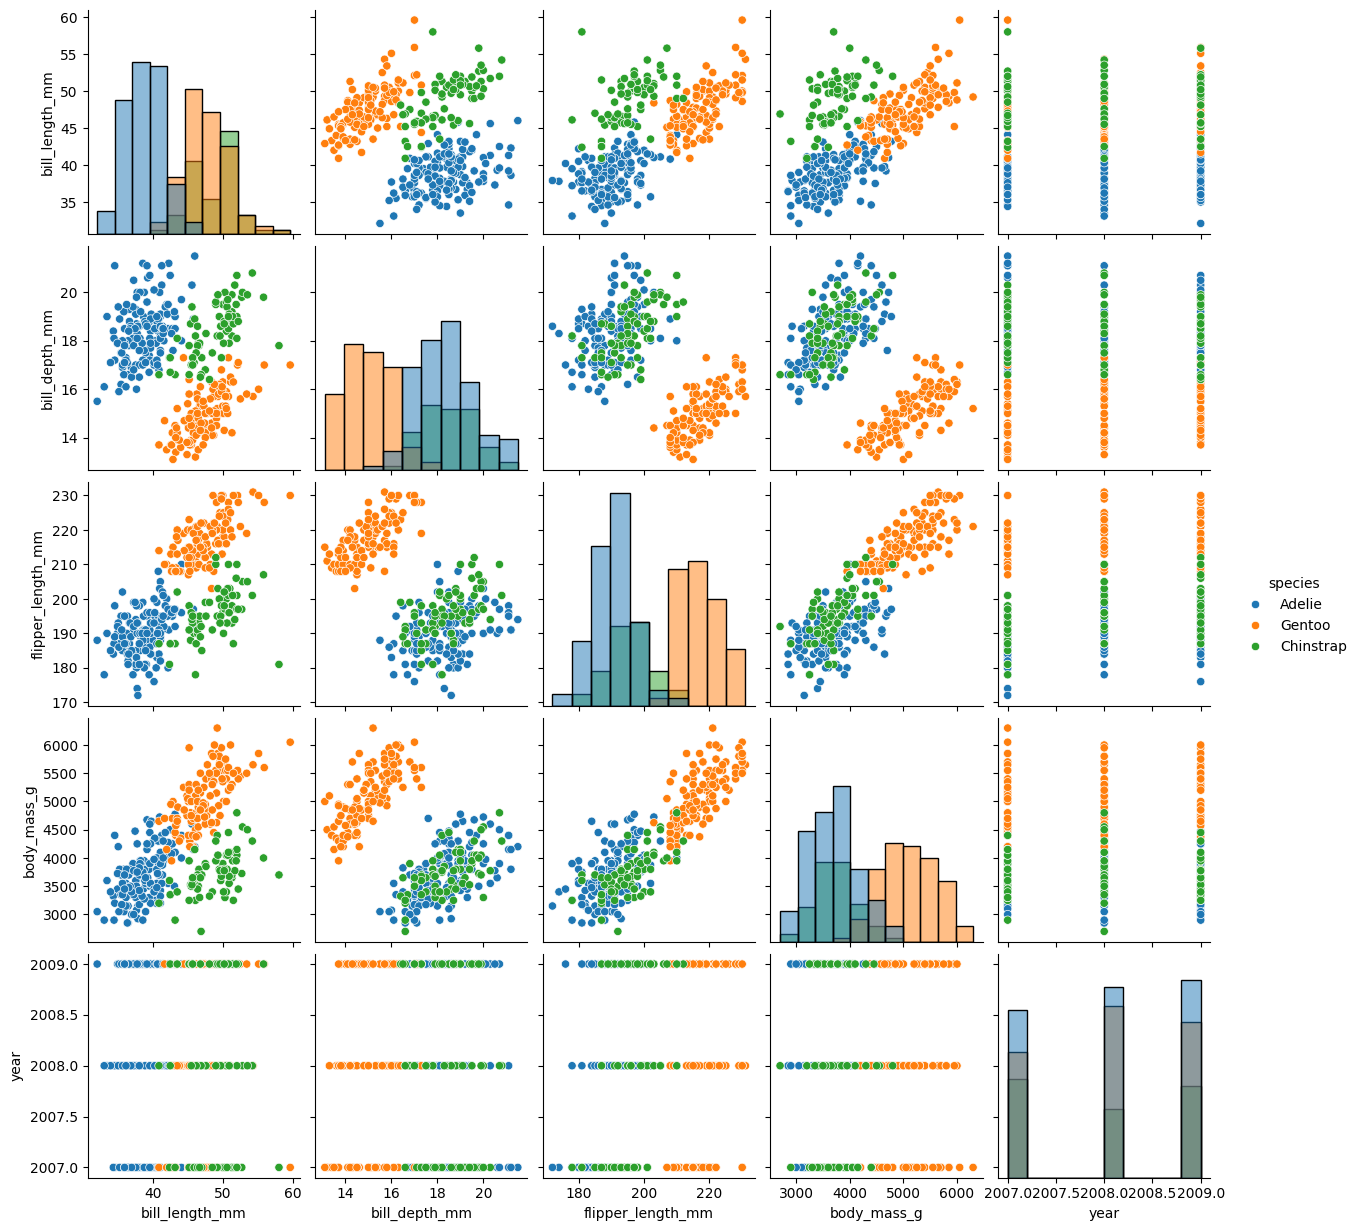

In [7]:
df = pd.read_csv(os.path.join(path, "palmerpenguins_original.csv"))

na_counts = df.isna().sum().sort_values(ascending=False)
display(na_counts[na_counts > 0])
df_clean = df.dropna().copy()

sns.pairplot(df_clean, hue='species', diag_kind='hist')
plt.show()


Question:

**Q1**: Do you observe overlap between species?

**Q2**:Which features seem most discriminative?

**Q1:**  Yes. There is noticeable overlap, especially between Adelie and Chinstrap across several feature pairs. In contrast, Gentoo forms a more clearly separated cluster and overlaps much less with the other two species.

**Q1:**  `flipper_length_mm` and `body_mass_g` are the most discriminative overall, clearly separating Gentoo. `bill_length_mm` and `bill depth` are more useful for distinguishing Adelie vs. Chinstrap.`Year` does not appear to be discriminative (species are mixed across years).

### 🧩 Step 3 — Split and Standardize

In [11]:
# Target
y = df_clean["species"].astype(str)

# Baseline features: numeric-only 
X_num = df_clean.select_dtypes(include="number").copy()

print("X_num shape:", X_num.shape)
print("y shape:", y.shape)
X_num.head()

# Encode target labels to integers for sklearn
le = LabelEncoder()
y_enc = le.fit_transform(y)

print("Classes:", list(le.classes_))
print("Encoded label sample:", y_enc[:10])

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_num, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc  # keep class proportions similar in train/test
)

print("Train:", X_train.shape, "Test:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train_scaled.shape[0], "Test size:", X_test_scaled.shape[0])

X_num shape: (333, 5)
y shape: (333,)
Classes: ['Adelie', 'Chinstrap', 'Gentoo']
Encoded label sample: [0 0 0 0 0 0 0 0 0 0]
Train: (266, 5) Test: (67, 5)
Train size: 266 Test size: 67


### 🔹 Step 4 — Train a Linear SVM

In [13]:
linear_svm = SVC(kernel="linear", C=1.0, random_state=42)
linear_svm.fit(X_train_scaled, y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False
